In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
train_data = pd.read_csv("../tmp/titanic/train.csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
test_data = pd.read_csv("../tmp/titanic/test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

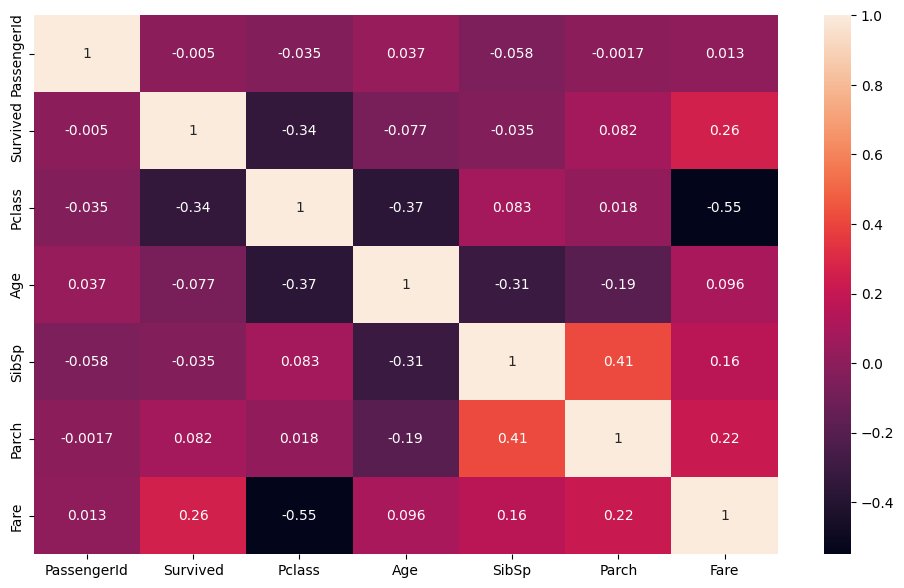

In [5]:
plt.figure(figsize=(12,7))
sns.heatmap(train_data.select_dtypes(include = ['number']).corr(), annot=True,)
plt.show()

# Version 3: Thay đổi việc xử lý missing value


<h3>Nhận xét thấy Age tương quan vừa với Pclass
-> Ta sẽ dùng IterativeImputer với X = Pclass, y là Age</h3>


In [6]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
from sklearn.linear_model import BayesianRidge
# imp = IterativeImputer(max_iter=10, random_state=0)

# --- BƯỚC 1: LỌC CÁC CỘT CẦN DÙNG ĐỂ IMUPUTE ---
# Ta chỉ cần 'Age' (cột có thiếu) và 'Pclass' (cột để dự đoán)
# Pclass cần được chuyển thành kiểu số nguyên nếu chưa phải
X_impute = train_data[['Age', 'Pclass']].copy()

# --- BƯỚC 2: KHỞI TẠO VÀ CẤU HÌNH IMputer ---
# Sử dụng BayesianRidge làm estimator thường tốt hơn LinearRegression mặc định
# Bạn có thể giữ mặc định nếu muốn, nhưng đây là một tùy chọn nâng cao.
estimator = BayesianRidge()
# imputer_age = IterativeImputer(
#     estimator=estimator,
#     max_iter=10, 
#     random_state=42 # Đặt random_state để đảm bảo kết quả có thể tái lập
# )
imputer_age = KNNImputer(
    n_neighbors=5,  
    weights='uniform' 
)

# --- BƯỚC 3: FIT VÀ TRANSFORM DỮ LIỆU ---
# Fit: huấn luyện mô hình dự đoán trên dữ liệu có sẵn
# Transform: áp dụng mô hình để điền khuyết các giá trị NaN
X_imputed_array = imputer_age.fit_transform(X_impute)

# --- BƯỚC 4: CẬP NHẬT DATAFRAME GỐC ---
# Lấy cột Age đã được điền khuyết (cột đầu tiên của mảng kết quả)
train_data['Age_Imputed'] = X_imputed_array[:, 0]

# Chuyển đổi Age_Imputed sang số nguyên nếu bạn muốn tuổi là số nguyên
train_data['Age_Imputed'] = train_data['Age_Imputed'].round().astype(int)

# In kết quả
print("\nDataFrame sau khi điền khuyết:")
print(train_data[['Age', 'Pclass', 'Age_Imputed']].sample(5))


DataFrame sau khi điền khuyết:
      Age  Pclass  Age_Imputed
465  38.0       3           38
776   NaN       3           25
309  30.0       1           30
369  24.0       1           24
208  16.0       3           16


In [7]:
train_data.drop(columns = ['Age'], inplace=True)

<h3>Xử lý missing value của cột Cabin<h/3>


In [8]:
pd.pivot_table(train_data, values='Survived', index='Cabin')

,Survived
Cabin,
A10,0.0
A14,0.0
A16,1.0
A19,0.0
A20,1.0
...,...
F33,1.0
F38,0.0
F4,1.0


In [9]:
sorted(train_data['Cabin'].dropna().values)

['A10',
 'A14',
 'A16',
 'A19',
 'A20',
 'A23',
 'A24',
 'A26',
 'A31',
 'A32',
 'A34',
 'A36',
 'A5',
 'A6',
 'A7',
 'B101',
 'B102',
 'B18',
 'B18',
 'B19',
 'B20',
 'B20',
 'B22',
 'B22',
 'B28',
 'B28',
 'B3',
 'B30',
 'B35',
 'B35',
 'B37',
 'B38',
 'B39',
 'B4',
 'B41',
 'B42',
 'B49',
 'B49',
 'B5',
 'B5',
 'B50',
 'B51 B53 B55',
 'B51 B53 B55',
 'B57 B59 B63 B66',
 'B57 B59 B63 B66',
 'B58 B60',
 'B58 B60',
 'B69',
 'B71',
 'B73',
 'B77',
 'B77',
 'B78',
 'B79',
 'B80',
 'B82 B84',
 'B86',
 'B94',
 'B96 B98',
 'B96 B98',
 'B96 B98',
 'B96 B98',
 'C101',
 'C103',
 'C104',
 'C106',
 'C110',
 'C111',
 'C118',
 'C123',
 'C123',
 'C124',
 'C124',
 'C125',
 'C125',
 'C126',
 'C126',
 'C128',
 'C148',
 'C2',
 'C2',
 'C22 C26',
 'C22 C26',
 'C22 C26',
 'C23 C25 C27',
 'C23 C25 C27',
 'C23 C25 C27',
 'C23 C25 C27',
 'C30',
 'C32',
 'C45',
 'C46',
 'C47',
 'C49',
 'C50',
 'C52',
 'C52',
 'C54',
 'C62 C64',
 'C65',
 'C65',
 'C68',
 'C68',
 'C7',
 'C70',
 'C78',
 'C78',
 'C82',
 'C83',
 'C

In [10]:
sum([1 for x in train_data['Cabin'].dropna() if len(x) > 4])

24

In [11]:
mask_not_na = train_data['Cabin'].notna()

# Điều kiện 2: Độ dài chuỗi Cabin > 4
# Ta chỉ áp dụng .str.len() lên các giá trị không phải NaN để tránh lỗi
# Nên ta kết hợp với mask_not_na. Khi kết hợp, NaN sẽ trở thành False trong mask
mask_long_cabin = train_data['Cabin'].str.len() > 4

# BƯỚC 2: Kết hợp các điều kiện lọc
# Lọc các hàng thỏa mãn CẢ HAI điều kiện
final_mask = mask_not_na & mask_long_cabin

# BƯỚC 3: Áp dụng mặt nạ lên DataFrame gốc
filtered_data = train_data[final_mask]

pd.crosstab(index = filtered_data['Cabin'], columns = filtered_data['Survived'])

Survived,0,1
Cabin,,
B51 B53 B55,1,1
B57 B59 B63 B66,0,2
B58 B60,1,1
B82 B84,1,0
B96 B98,0,4
C22 C26,2,1
C23 C25 C27,2,2
C62 C64,0,1
D10 D12,0,1


<h3>Cắt chữ đầu tin của Cabin </h3>


In [12]:
train_data['Cabin_first_letter'] = train_data['Cabin'].dropna().str[0]
print(train_data['Cabin_first_letter'])

0      NaN
1        C
2      NaN
3        C
4      NaN
      ... 
886    NaN
887      B
888    NaN
889      C
890    NaN
Name: Cabin_first_letter, Length: 891, dtype: object


<h3>Kiểm tra độ phân phối của Cabin với các biến khác</h3>


In [13]:
mask_not_na = train_data['Cabin_first_letter'].notna()

# Lọc các hàng thỏa mãn điều kiện
# Áp dụng mặt nạ lên DataFrame gốc
filtered_data = train_data[mask_not_na]

pd.crosstab(index = filtered_data['Cabin_first_letter'], columns = filtered_data['Survived'])

Survived,0,1
Cabin_first_letter,,
A,8,7
B,12,35
C,24,35
D,8,25
E,8,24
F,5,8
G,2,2
T,1,0


In [14]:
pd.crosstab(index = filtered_data['Cabin_first_letter'], columns = filtered_data['Pclass'])

Pclass,1,2,3
Cabin_first_letter,,,
A,15,0,0
B,47,0,0
C,59,0,0
D,29,4,0
E,25,4,3
F,0,8,5
G,0,0,4
T,1,0,0


In [15]:
pd.crosstab(index = filtered_data['Cabin_first_letter'], columns = filtered_data['SibSp'])

SibSp,0,1,2,3
Cabin_first_letter,,,,
A,13,2,0,0
B,32,13,2,0
C,29,25,2,3
D,19,14,0,0
E,22,10,0,0
F,8,3,2,0
G,2,2,0,0
T,1,0,0,0


<h3>Xác định Cabin có quan hệ mạnh với Pclass -> Ta sẽ cho học Cabin-Pclass</h3>


<h3>Trước tiên, map cho cabin_first_letter thành số để có thể học</h3>


In [16]:
train_data['Cabin_first_letter'] = train_data['Cabin_first_letter'].map({'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'T': 7})

<h3>Xử lý missing sau khi cắt bằng IterativeImputer</h3>


In [17]:
# --- BƯỚC 1: LỌC CÁC CỘT CẦN DÙNG ĐỂ IMUPUTE ---
# Ta chỉ cần 'Age' (cột có thiếu) và 'Pclass' (cột để dự đoán)
# Pclass cần được chuyển thành kiểu số nguyên nếu chưa phải
X_impute = train_data[['Cabin_first_letter', 'Pclass']].copy()

# --- BƯỚC 2: KHỞI TẠO VÀ CẤU HÌNH IMputer ---
# Sử dụng BayesianRidge làm estimator thường tốt hơn LinearRegression mặc định
# Bạn có thể giữ mặc định nếu muốn, nhưng đây là một tùy chọn nâng cao.
estimator = BayesianRidge()
# imputer_cabin = IterativeImputer(
#     estimator=estimator,
#     max_iter=10, 
#     random_state=42 # Đặt random_state để đảm bảo kết quả có thể tái lập
# )
imputer_cabin = KNNImputer(
    n_neighbors=5,  
    weights='uniform' 
)

# --- BƯỚC 3: FIT VÀ TRANSFORM DỮ LIỆU ---
# Fit: huấn luyện mô hình dự đoán trên dữ liệu có sẵn
# Transform: áp dụng mô hình để điền khuyết các giá trị NaN
X_imputed_array = imputer_cabin.fit_transform(X_impute)

# --- BƯỚC 4: CẬP NHẬT DATAFRAME GỐC ---
# Lấy cột Age đã được điền khuyết (cột đầu tiên của mảng kết quả)
train_data['Cabin_Imputed'] = X_imputed_array[:, 0]


<h3>Xử lý missing value Embarked dễ dàng vì chỉ có vài dòng bị mất</h3>


In [18]:
# Gán giá trị mode (giá trị xuất hiện nhiều nhất) cho các giá trị missing của cột "Embarked" 
most_common_embarked = train_data['Embarked'].mode()[0]
train_data['Embarked'] = train_data['Embarked'].fillna(most_common_embarked)

# # Gán giá trị trung bình cho các giá trị  missing của cột "Age"
# train_data['Age'] = train_data['Age'].fillna(train_data['Age'].median())

# Xóa cột "Cabin" khỏi dataFrame vì quá nhiều hàng missing
# train_data.drop(columns=['Cabin'], inplace=True)
# test_data.drop(columns=['Cabin'], inplace=True)

train_data.drop(columns=['PassengerId'], inplace=True)
test_data.drop(columns=['PassengerId'], inplace=True)

<h3>Kiểm tra hết missing value chưa</h3>


In [19]:
train_data.isna().sum()

Survived                0
Pclass                  0
Name                    0
Sex                     0
SibSp                   0
Parch                   0
Ticket                  0
Fare                    0
Cabin                 687
Embarked                0
Age_Imputed             0
Cabin_first_letter    687
Cabin_Imputed           0
dtype: int64

In [20]:
train_data.drop(columns=['Cabin', 'Cabin_first_letter'], inplace=True)

In [21]:
train_data.isna().sum()

Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
Age_Imputed      0
Cabin_Imputed    0
dtype: int64

<h3>Kiểm tra missing value bên tập test</h3>


In [22]:
test_data.isna().sum()

Pclass        0
Name          0
Sex           0
Age          86
SibSp         0
Parch         0
Ticket        0
Fare          1
Cabin       327
Embarked      0
dtype: int64

<h3>Xử lý missing Age</h3>


In [23]:
X_impute = test_data[['Age', 'Pclass']].copy()
X_imputed_array = imputer_age.transform(X_impute)
test_data['Age_Imputed'] = X_imputed_array[:, 0]
test_data['Age_Imputed'] = test_data['Age_Imputed'].round().astype(int)

<h3>Xử lý missing fare dễ dàng vì chỉ mất 1 hàng</h3>


In [24]:
test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].median())

<h3>Xử lý missing Cabin như tập train</h3>


In [25]:
test_data['Cabin_first_letter'] = test_data['Cabin'].str[0]
test_data['Cabin_first_letter'] = test_data['Cabin_first_letter'].map({'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'T': 7})

In [26]:
X_impute = test_data[['Cabin_first_letter', 'Pclass']].copy()
X_imputed_array = imputer_cabin.transform(X_impute)

# --- BƯỚC 4: CẬP NHẬT DATAFRAME GỐC ---
# Lấy cột Age đã được điền khuyết (cột đầu tiên của mảng kết quả)
test_data['Cabin_Imputed'] = X_imputed_array[:, 0]

<h3>Kiểm tra còn missing value không


In [27]:
test_data.isna().sum()

Pclass                  0
Name                    0
Sex                     0
Age                    86
SibSp                   0
Parch                   0
Ticket                  0
Fare                    0
Cabin                 327
Embarked                0
Age_Imputed             0
Cabin_first_letter    327
Cabin_Imputed           0
dtype: int64

In [28]:
test_data.drop(columns=['Age', 'Cabin', 'Cabin_first_letter'], inplace=True)

In [29]:
test_data.isna().sum()

Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
Age_Imputed      0
Cabin_Imputed    0
dtype: int64

In [30]:
print(train_data.isna().sum().sum())
print(test_data.isna().sum().sum())

0
0


<h3>Drop cột ticket


In [31]:
train_data.drop(columns=['Ticket', 'Cabin_Imputed'], inplace=True)
test_data.drop(columns=['Ticket', 'Cabin_Imputed'], inplace=True)

<h3>Mã hóa cột Sex thành 0 - 1


In [32]:
# Map male - 0, fale - 1
train_data['Sex'] = train_data['Sex'].map({'male': 0, 'female': 1})
test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1})

<h3>Xử lý name cho 2 tập bằng cách cắt ra từ đầu tiên sau dấu phẩy (Mr, Mrs, Dr,..)


In [33]:
# 1. Tạo name_title từ Name (làm trước khi drop)
train_data['name_title'] = train_data.Name.apply(lambda x: x.split(',')[1].split('.')[0].strip())
test_data['name_title'] = test_data.Name.apply(lambda x: x.split(',')[1].split('.')[0].strip())

# 2. Lấy top 5 title phổ biến nhất
top_5_titles = train_data['name_title'].value_counts().head(5).index.tolist()
print("Top 5 titles:", top_5_titles)

# 3. Gom tất cả title khác thành "Other"
train_data['name_title'] = train_data['name_title'].apply(lambda x: x if x in top_5_titles else 'Other')
test_data['name_title'] = test_data['name_title'].apply(lambda x: x if x in top_5_titles else 'Other')

# 4. Kiểm tra kết quả - CHỈ CÒN 6 CATEGORIES
print("\nAfter grouping - chỉ còn 6 categories:")
print(train_data['name_title'].value_counts())
print("\nTest data name_title counts:")
print(test_data['name_title'].value_counts())

# 5. Sau đó mới drop column Name
train_data.drop(columns=['Name'], inplace=True)
test_data.drop(columns=['Name'], inplace=True)


Top 5 titles: ['Mr', 'Miss', 'Mrs', 'Master', 'Dr']

After grouping - chỉ còn 6 categories:
name_title
Mr        517
Miss      182
Mrs       125
Master     40
Other      20
Dr          7
Name: count, dtype: int64

Test data name_title counts:
name_title
Mr        240
Miss       78
Mrs        72
Master     21
Other       6
Dr          1
Name: count, dtype: int64


<h3>Xử lý family


In [34]:
# train_data['Family_Size'] = train_data['SibSp'].astype('int') + train_data['Parch'].astype('int') + 1
# test_data['Family_Size'] = test_data['SibSp'].astype('int') + test_data['Parch'].astype('int') + 1

In [35]:
# sns.countplot(data=train_data,x='Family_Size', hue='Survived')

In [36]:
# # Cắt các giá trị theo khoảng và gắn labels
# train_data['Family_Cat'] = pd.cut(train_data['Family_Size'], bins=[0,1,4,6,20], labels=['Alone', 'Small', 'Medium', 'Large'])
# test_data['Family_Cat'] = pd.cut(test_data['Family_Size'], bins=[0,1,4,6,20], labels=['Alone', 'Small', 'Medium', 'Large']) 

In [37]:
# train_data['Family_Cat'] = train_data['Family_Cat'].map({'Alone': 0, 'Small': 1, 'Medium': 2, 'Large': 3})
# test_data['Family_Cat'] = test_data['Family_Cat'].map({'Alone': 0, 'Small': 1, 'Medium': 2, 'Large': 3})
# train_data['Family_Cat'] = train_data['Family_Cat'].astype('int64')
# test_data['Family_Cat'] = test_data['Family_Cat'].astype('int64')

In [38]:
# train_data.drop(columns=['SibSp', 'Parch', 'Family_Size'], inplace=True)
# test_data.drop(columns=['SibSp', 'Parch', 'Family_Size'], inplace=True)

<h3>Dummies để tăng hiệu suất train


In [39]:
train_data.isna().sum()

Survived       0
Pclass         0
Sex            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Age_Imputed    0
name_title     0
dtype: int64

In [40]:
train_data['Embarked'].value_counts

<bound method IndexOpsMixin.value_counts of 0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object>

In [41]:
pd.crosstab(index=train_data['Embarked'], columns=train_data['Survived'])

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,219


In [42]:
train_data['Embarked'] = train_data['Embarked'].map({'C': 1, 'Q': 2, 'S': 3})
test_data['Embarked'] = test_data['Embarked'].map({'C': 1, 'Q': 2, 'S': 3})

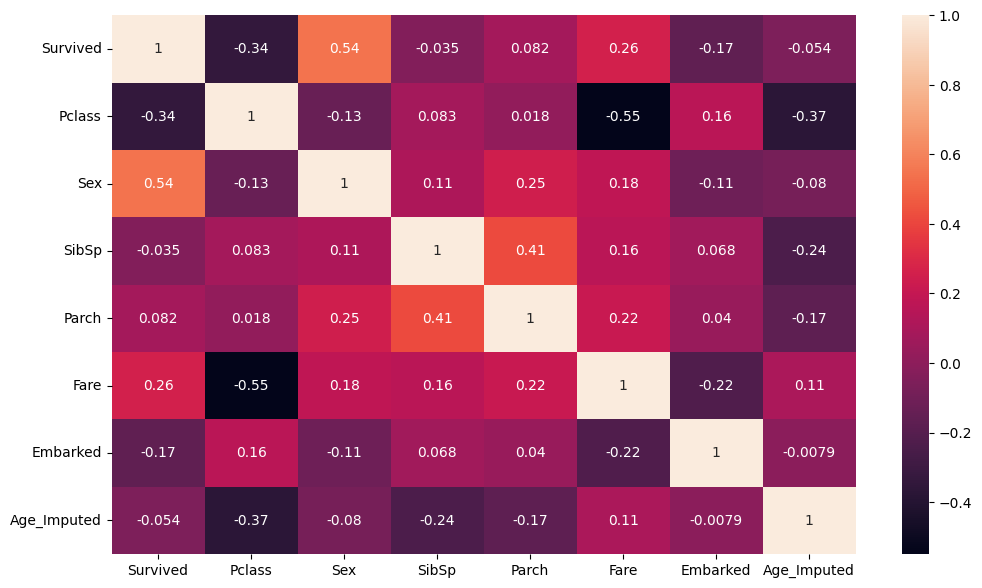

In [43]:
plt.figure(figsize=(12,7))
sns.heatmap(train_data.select_dtypes(include = ['number']).corr(), annot=True,)
plt.show()

In [44]:
train_data.isna().sum()

Survived       0
Pclass         0
Sex            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Age_Imputed    0
name_title     0
dtype: int64

In [45]:
# train_data.drop(columns=['Embarked'], inplace=True)
# test_data.drop(columns=['Embarked'], inplace=True)
# train_data.drop(columns=['Age_Imputed'], inplace=True)
# test_data.drop(columns=['Age_Imputed'], inplace=True)

In [46]:
# train_data['SibSp/Parch'] = (train_data['SibSp'] + 1) / (train_data['Parch'] + 1) # Criação de uma mescla de features
# test_data['SibSp/Parch'] = (test_data['SibSp'] + 1) / (test_data['Parch'] + 1) # Criação de uma mescla de features

In [47]:
# train_data['Fare'] = np.log1p(train_data['Fare'].clip(lower=0))
# test_data['Fare'] = np.log1p(test_data['Fare'].clip(lower=0))

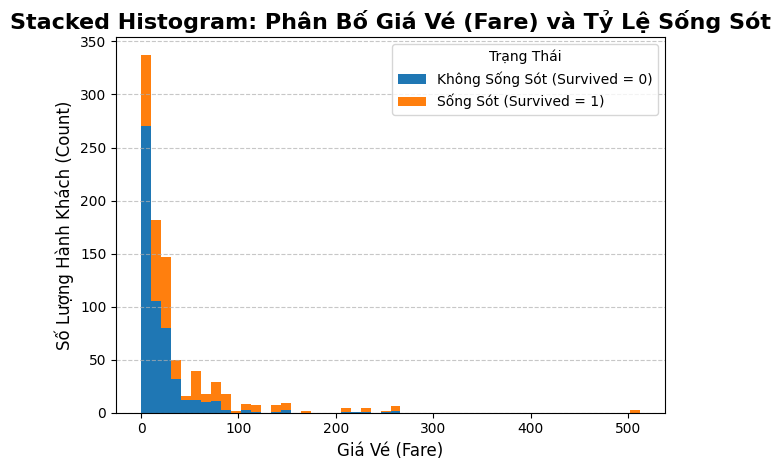

In [48]:
pd.crosstab(index=train_data['Fare'], columns = train_data['Survived'])
x_data1 = train_data[train_data['Survived'] == 0]['Fare']
x_data2 = train_data[train_data['Survived'] == 1]['Fare']
x_data = [x_data1, x_data2]
labels = ['Không Sống Sót (Survived = 0)', 'Sống Sót (Survived = 1)']
plt.hist(x_data, bins = 50, stacked=True, label=labels)
plt.title('Stacked Histogram: Phân Bố Giá Vé (Fare) và Tỷ Lệ Sống Sót', fontsize=16, fontweight='bold')
plt.xlabel('Giá Vé (Fare)', fontsize=12)
plt.ylabel('Số Lượng Hành Khách (Count)', fontsize=12)
plt.legend(loc='upper right', title="Trạng Thái")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [49]:
train_data['Fare'].value_counts

<bound method IndexOpsMixin.value_counts of 0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 891, dtype: float64>

In [50]:
# Cắt các giá trị theo khoảng và gắn labels
train_data['Fare_Cat'] = pd.cut(train_data['Fare'], bins=[0,40,80,200,1000], labels=['so_cheap', 'cheap', 'Medium', 'Expensive'])
test_data['Fare_Cat'] = pd.cut(test_data['Fare'], bins=[0,40,80,200,1000], labels=['so_cheap', 'cheap', 'Medium', 'Expensive']) 
# train_data['Fare_Cat'] = train_data['Fare_Cat'].map({'so_cheap':1, 'cheap':2, 'Medium':3, 'Expensive':4})
# test_data['Fare_Cat'] = test_data['Fare_Cat'].map({'so_cheap':1, 'cheap':2, 'Medium':3, 'Expensive':4})
# train_data['Fare_Cat'].astype('int')
# test_data['Fare_Cat'].astype('int')

In [51]:
dummies_col = ['name_title', 'Fare_Cat']
for col in dummies_col:
    train_data = pd.get_dummies(train_data, columns=[col], drop_first=True)
    test_data = pd.get_dummies(test_data, columns=[col], drop_first=True)

train_data.drop(columns=['Fare'], inplace=True)
test_data.drop(columns=['Fare'], inplace=True)

In [52]:
# d,;adlasdasd

In [53]:
# cols = ['SibSp', 'Parch']
# for col in cols:
#     train_data.drop(columns=[col], inplace=True)
#     test_data.drop(columns=[col], inplace=True)

In [54]:
train_data.isna().sum()

Survived              0
Pclass                0
Sex                   0
SibSp                 0
Parch                 0
Embarked              0
Age_Imputed           0
name_title_Master     0
name_title_Miss       0
name_title_Mr         0
name_title_Mrs        0
name_title_Other      0
Fare_Cat_cheap        0
Fare_Cat_Medium       0
Fare_Cat_Expensive    0
dtype: int64

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
scaler = StandardScaler()
normalizer = Normalizer()
for col in ['Age_Imputed']:
    train_data[col] = scaler.fit_transform(train_data[[col]])
    test_data[col] = scaler.transform(test_data[[col]])
    # train_data[col] = normalizer.fit_transform(train_data[[col]])
    # test_data[col] = normalizer.transform(test_data[[col]])

In [56]:
train_data.isna().sum()

Survived              0
Pclass                0
Sex                   0
SibSp                 0
Parch                 0
Embarked              0
Age_Imputed           0
name_title_Master     0
name_title_Miss       0
name_title_Mr         0
name_title_Mrs        0
name_title_Other      0
Fare_Cat_cheap        0
Fare_Cat_Medium       0
Fare_Cat_Expensive    0
dtype: int64

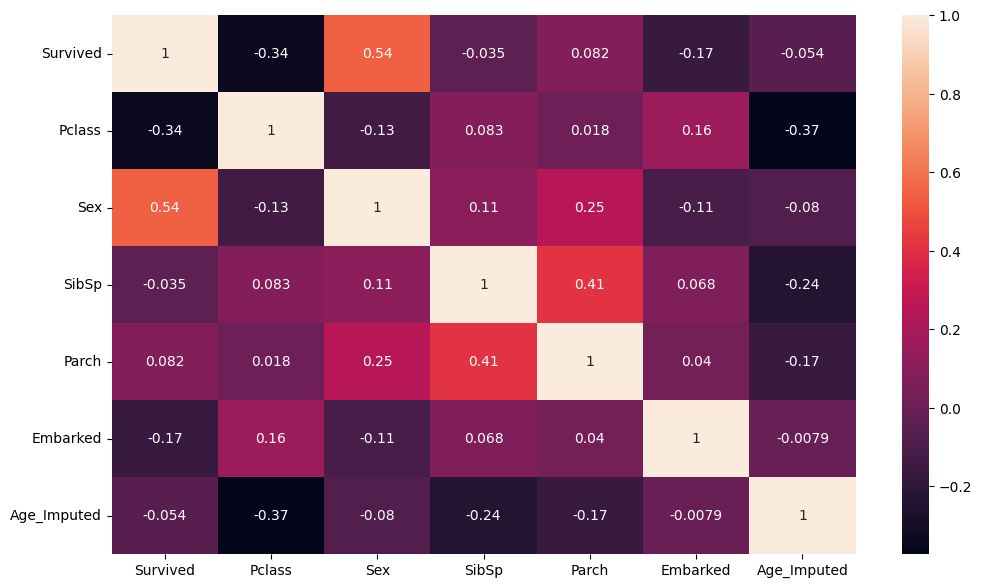

In [57]:
plt.figure(figsize=(12,7))
sns.heatmap(train_data.select_dtypes(include = ['number']).corr(), annot=True,)
plt.show()

In [58]:
sum([1 for _ in train_data.columns])

15

In [59]:
fdfdf

NameError: name 'fdfdf' is not defined

In [ ]:
from sklearn.model_selection import train_test_split

X = train_data.drop('Survived', axis=1)
y = train_data['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=200),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:,1]

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_prob)

    print(f"{name} Results:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  ROC AUC:  {roc_auc:.4f}")
    print("-" * 30)

Logistic Regression Results:
  Accuracy: 0.8436
  F1 Score: 0.7879
  ROC AUC:  0.8767
------------------------------
Random Forest Results:
  Accuracy: 0.8045
  F1 Score: 0.7407
  ROC AUC:  0.8487
------------------------------
XGBoost Results:
  Accuracy: 0.8156
  F1 Score: 0.7481
  ROC AUC:  0.8468
------------------------------


In [ ]:
best_model = LogisticRegression(random_state=42, max_iter=1000)
# best_model = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=200)
# best_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)

y_val_pred = best_model.predict(X_val)

print("Actual values (first 5):")
print(y_val.head())

print("\nPredicted values (first 5):")
print(pd.Series(y_val_pred).head())

Actual values (first 5):
565    0
160    0
553    1
860    0
241    1
Name: Survived, dtype: int64

Predicted values (first 5):
0    0
1    0
2    0
3    0
4    1
dtype: int64


In [ ]:
# Orijinal test csv'sini tekrar yükle (PassengerId için)
test_data_orig = pd.read_csv("/kaggle/input/titanic/test.csv")

# 1. Lấy danh sách tên cột từ tập huấn luyện (X_train)
# Đây là danh sách các cột mà mô hình của bạn đã được fit (học).
# LƯU Ý: Phải sử dụng X_train (hoặc biến chứa các features đã dùng để fit mô hình)
feature_cols_at_fit = X_train.columns

# 2. Đồng bộ hóa tập test_data
# Đảm bảo test_data có số lượng cột, tên cột và thứ tự cột giống hệt X_train.
# Các cột thiếu (ví dụ: 'Cabin_Imputed_7.0') sẽ được thêm vào với giá trị 0.
test_data_aligned = test_data.reindex(columns=feature_cols_at_fit, fill_value=0)

# best_model ile test verisi üzerinde tahmin yap
test_preds = best_model.predict(test_data_aligned)

# Submission dataframe'i oluştur
submission = pd.DataFrame({
    "PassengerId": test_data_orig["PassengerId"],
    "Survived": test_preds
})

# CSV olarak kaydet (kaggle ortamında)
submission.to_csv("submission.csv", index=False)

print("Submission file 'submission.csv' created.")

Submission file 'submission.csv' created.
